In [21]:
from IPython.display import Image
import h5py
from matplotlib import pyplot as plt
import numpy as np
import os

In [22]:
# importing my analysis tools
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parents[1]) + "/analysis-tools")
import plotting_tools as pt

In [23]:
# source qdev/bin/activate  "activates my venv", can check pip list here 
# data path
path = "/run/media/raveel/Crucial X9/qdg/masters/experiments/antidot-0626/data/"

$$ C_g = \frac{e}{\Delta V_g} $$

$$ C_g = \epsilon_r \epsilon_0 \frac A d $$


$A$ = island area
$d$ = hBN thickness
$V_g$ = distance between N & N+1 occupation

$$E_c = \frac{e^2}{2C_\Sigma} =  \frac{e\Delta V_{sd}}{2} = {[C][V] = J}$$
$$E_c(eV) = \frac{e}{2C_\Sigma} =  \frac{\Delta V_{sd}}{2} = {[C][V]/e[C] = eV}$$
$$\alpha = \frac{C_g}{C_\Sigma}$$


In [24]:
def SET_Cg(V_g):
    e = 1.602e-19
    return e/V_g

def SET_island_area(d, V_g):
    eps_0 = 8.85e-12
    eps_r = 3.4
    area = SET_Cg(V_g) * d / eps_0 / eps_r
    return np.round(area * 1e6 * 1e6,8)

def SET_Ec(V_sd):
    #e = 1.602e-19
    return V_sd/2

def SET_Ctot(V_sd):
    e = 1.602e-19
    return e/2/SET_Ec(V_sd)

def SET_alpha(V_g, V_sd):
    return np.round(SET_Cg(V_g) / SET_Ctot(V_sd), 2)

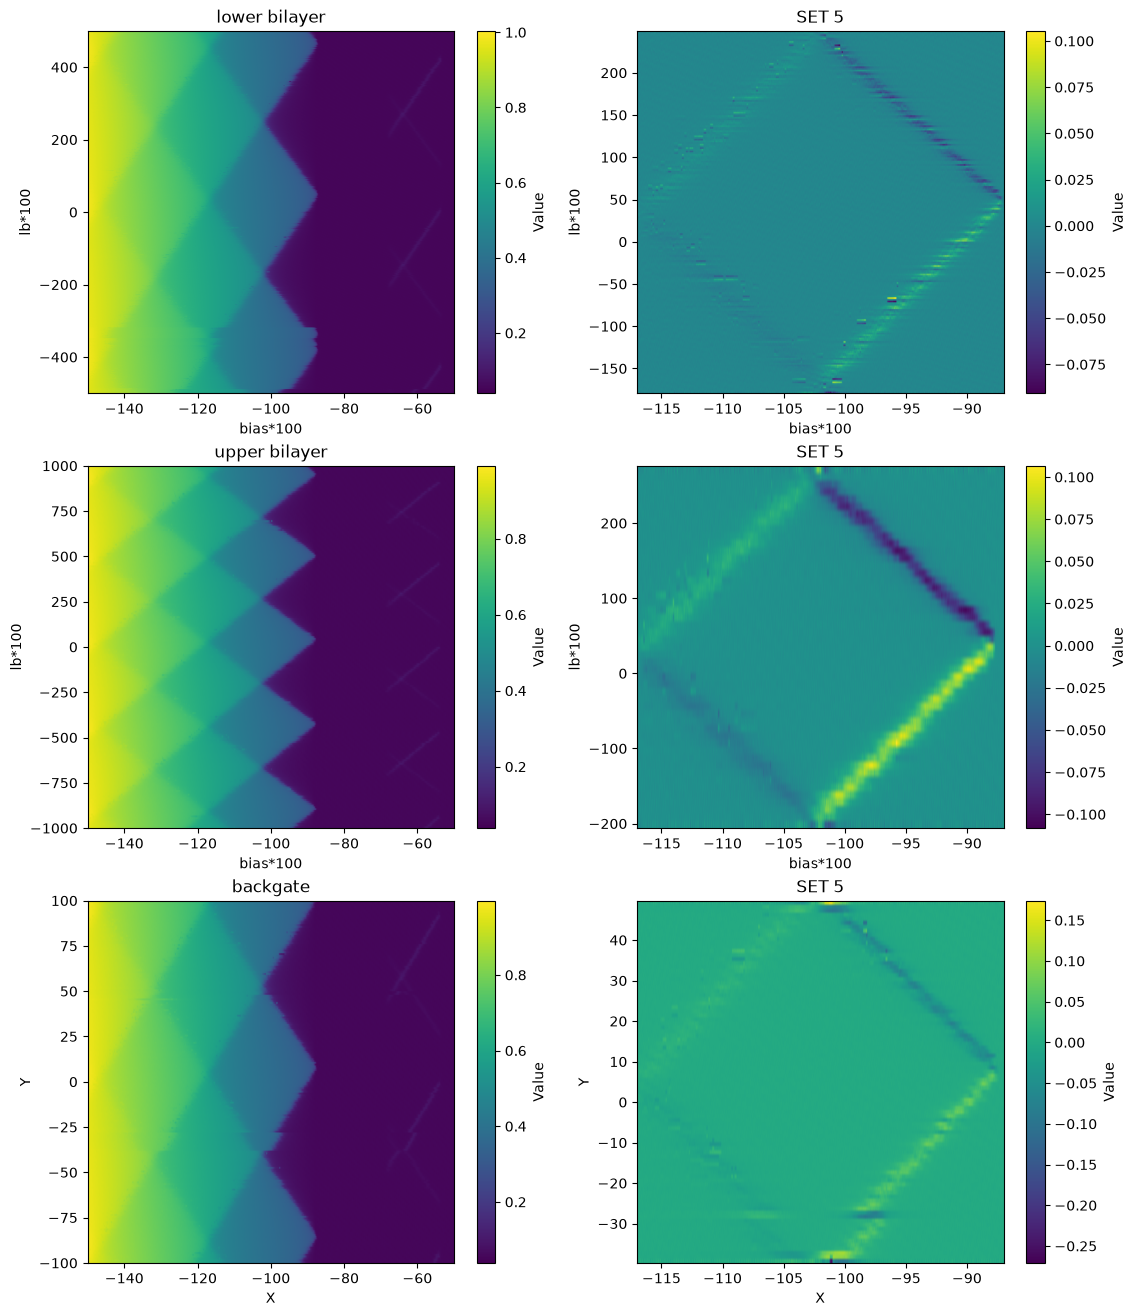

In [16]:
fig, ax = plt.subplots(3, 2, figsize=(13,16))

pt.plot_h5_2d(path+'dat43.h5', 'SET5_2d', gradient_axis=None, ax = ax[0,0], title = "lower bilayer", ylabel = "lb*100", xlabel = "bias*100")
pt.plot_h5_2d(path+'dat43.h5', 'SET5_2d', gradient_axis=0, ax = ax[0,1], title = "SET 5", ylabel = "lb*100", xlabel = "bias*100",xlim = (-117, -87), ylim = (-180,250))
pt.plot_h5_2d(path+'dat50.h5', 'SET5_2d', gradient_axis=None, ax = ax[1,0], title = "upper bilayer", ylabel = "lb*100", xlabel = "bias*100")
pt.plot_h5_2d(path+'dat50.h5', 'SET5_2d', gradient_axis=0, ax = ax[1,1], title = "SET 5", ylabel = "lb*100", xlabel = "bias*100", xlim = (-117, -87), ylim = (-210,280))
pt.plot_h5_2d(path+'dat52.h5', 'SET5_2d', gradient_axis=None, ax = ax[2,0], title = "backgate")# xlim = (80,130))
pt.plot_h5_2d(path+'dat52.h5', 'SET5_2d', gradient_axis=0, ax = ax[2,1], title = "SET 5", ylim = (-40,50), xlim = (-117,-87))

### charging energy, SET island area and lever arm based on bilayer gating

In [17]:
print(SET_island_area(80e-9, 4.3e-3), "um^2")
print('E_c=',SET_Ec(30e-3/100) * 1e6, "ueV")
print("alpha =", SET_alpha(4.3e-3, 30e-3/100))

0.09905168 um^2
E_c= 150.0 ueV
alpha = 0.07


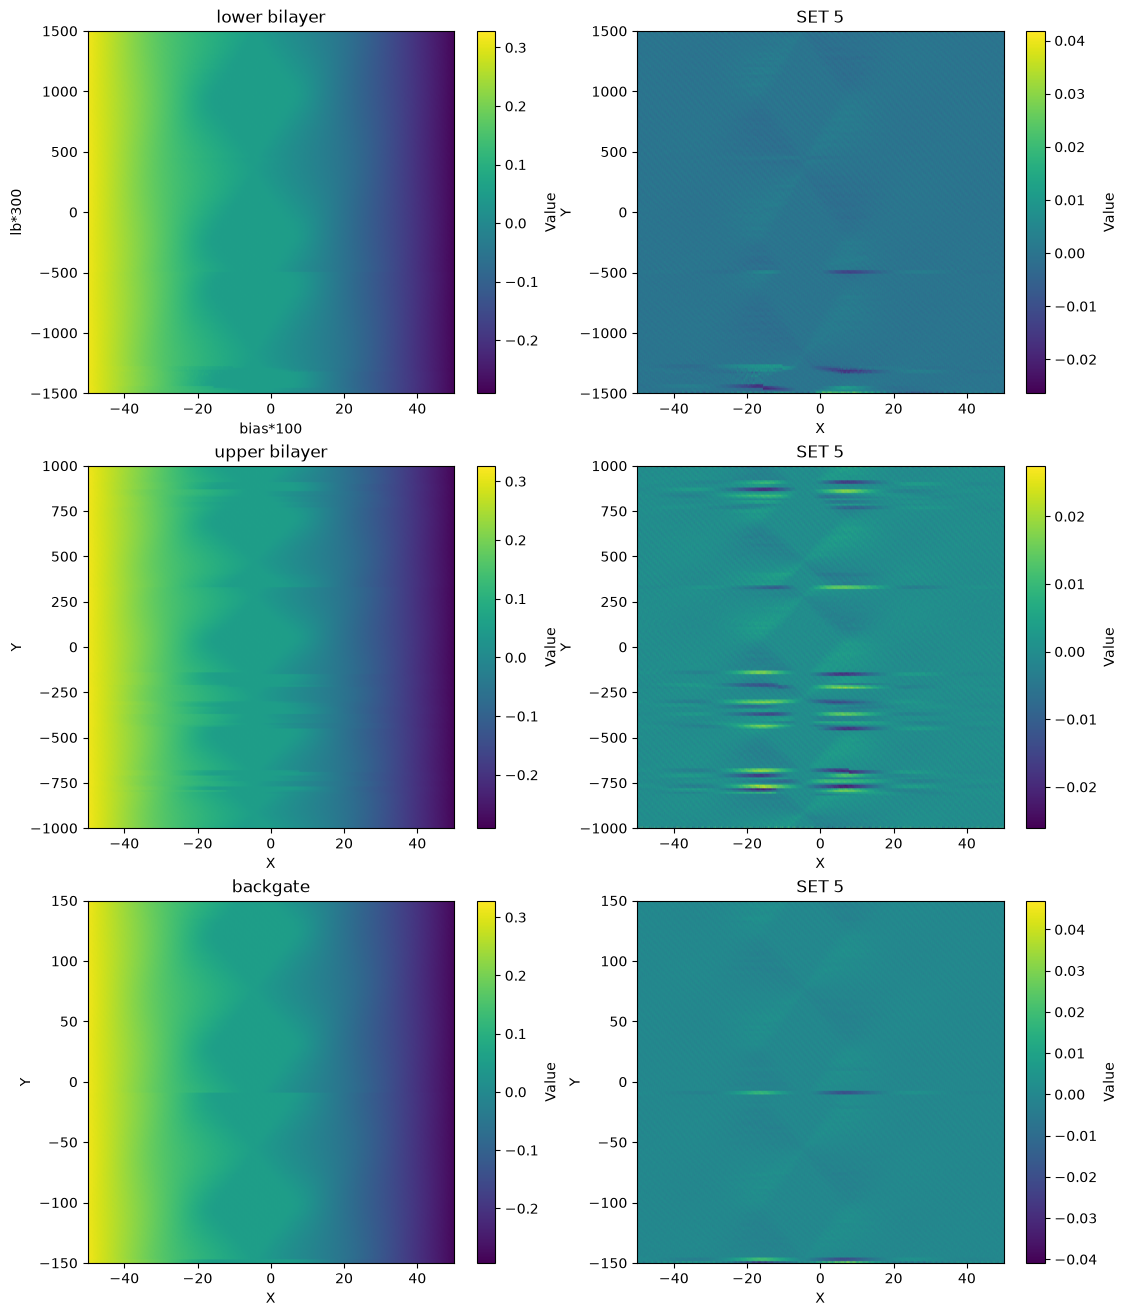

In [19]:
fig, ax = plt.subplots(3, 2, figsize=(13,16))

pt.plot_h5_2d(path+'dat76.h5', 'SET5_2d', gradient_axis=None, ax = ax[0,0], title = "lower bilayer", ylabel = "lb*300", xlabel = "bias*100")
pt.plot_h5_2d(path+'dat76.h5', 'SET5_2d', gradient_axis=0, ax = ax[0,1], title = "SET 5")# xlim = (-150,-50))
pt.plot_h5_2d(path+'dat75.h5', 'SET5_2d', gradient_axis=None, ax = ax[1,0], title = "upper bilayer")# xlim = (80,130), ylim = (-150,150))
pt.plot_h5_2d(path+'dat75.h5', 'SET5_2d', gradient_axis=0, ax = ax[1,1], title = "SET 5")#xlim = (80,130), ylim = (-150,150))
pt.plot_h5_2d(path+'dat78.h5', 'SET5_2d', gradient_axis=None, ax = ax[2,0], title = "backgate")# xlim = (80,130))
pt.plot_h5_2d(path+'dat78.h5', 'SET5_2d', gradient_axis=0, ax = ax[2,1], title = "SET 5")#xlim = (80,130))

In [28]:
## fridge
kb = 8.6e-5 #eV/K
T = 500e-3 #K
kb * T * 1e6

43.0